In [1]:
import os
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
import json

# Replace with your username and key
kaggle_json = {
    "username": "labidimahdi",
    "key": "KGAT_cd508928a093f9d98f6e6c791a532e15"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download adityamahimkar/iqothnccd-lung-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
 74% 147M/199M [00:00<00:00, 1.54GB/s]
100% 199M/199M [00:00<00:00, 1.03GB/s]


In [4]:
!unzip /content/iqothnccd-lung-cancer-dataset.zip

Archive:  /content/iqothnccd-lung-cancer-dataset.zip
  inflating: Test cases/000001_03_01_088.png  
  inflating: Test cases/000017_02_01_016.png  
  inflating: Test cases/000019_01_01_021.png  
  inflating: Test cases/000019_02_01_025.png  
  inflating: Test cases/000019_03_01_025.png  
  inflating: Test cases/000020_01_01_066.png  
  inflating: Test cases/000020_02_01_062.png  
  inflating: Test cases/000020_03_01_134.png  
  inflating: Test cases/000020_03_01_166.png  
  inflating: Test cases/000020_03_01_212.png  
  inflating: Test cases/000020_04_01_116.png  
  inflating: Test cases/000020_04_01_143.png  
  inflating: Test cases/000020_04_01_159.png  
  inflating: Test cases/000021_01_01_016.png  
  inflating: Test cases/000021_02_01_068.png  
  inflating: Test cases/000021_03_01_012.png  
  inflating: Test cases/000021_03_01_017.png  
  inflating: Test cases/000021_04_01_090.png  
  inflating: Test cases/000027_01_01_113.png  
  inflating: Test cases/000027_02_01_105.png  
  infla

In [5]:
ORIGINAL_DATA_DIR = './The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
SPLIT_DATA_DIR = './data_split'

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'valid')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [6]:
def rename_images(data_dir):

    classes = [d for d in os.listdir(data_dir)
               if os.path.isdir(os.path.join(data_dir, d))]

    for class_name in classes:
        class_images_path = os.path.join(data_dir, class_name)

        images = [f for f in os.listdir(class_images_path)
                  if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"{class_name}: {len(images)} images")

        for i, image_name in enumerate(images):
            old_path = os.path.join(class_images_path, image_name)
            new_path = os.path.join(class_images_path, f"{class_name}_{i}.jpg")

            if old_path == new_path:
                continue

            try:
                shutil.copy2(old_path, new_path)
                os.remove(old_path)
            except OSError as e:
                print(f"Failed: {image_name} → {e}")

        print(f"Done: {class_name}")

rename_images(ORIGINAL_DATA_DIR)

Bengin cases: 120 images
Done: Bengin cases
Malignant cases: 561 images
Done: Malignant cases
Normal cases: 416 images
Done: Normal cases


In [7]:
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir,
                          split_ratio=(0.70, 0.15, 0.15), seed=42):

    random.seed(seed)

    classes = [d for d in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, d))]

    print(f"Found {len(classes)} classes: {classes}\n")

    for class_name in classes:

        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir,   class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir,  class_name), exist_ok=True)

        class_folder = os.path.join(source_dir, class_name)
        images = [f for f in os.listdir(class_folder)
                  if f.endswith(('.jpg', '.jpeg', '.png'))]

        random.shuffle(images)

        train_count = int(len(images) * split_ratio[0])
        val_count   = int(len(images) * split_ratio[1])

        train_images = images[:train_count]
        val_images   = images[train_count : train_count + val_count]
        test_images  = images[train_count + val_count:]

        for img in train_images:
            shutil.copy(
                os.path.join(class_folder, img),
                os.path.join(train_dir, class_name, img)
            )

        for img in val_images:
            shutil.copy(
                os.path.join(class_folder, img),
                os.path.join(val_dir, class_name, img)
            )

        for img in test_images:
            shutil.copy(
                os.path.join(class_folder, img),
                os.path.join(test_dir, class_name, img)
            )

        print(f" {class_name}: {len(images)} images → "
              f"train={len(train_images)} | "
              f"val={len(val_images)} | "
              f"test={len(test_images)}")

    print("\n Done! Dataset is ready.")


create_dataset_splits(
    source_dir  = ORIGINAL_DATA_DIR,
    train_dir   = TRAIN_DIR,
    val_dir     = VAL_DIR,
    test_dir    = TEST_DIR,
    split_ratio = (0.70, 0.15, 0.15)
)

Found 3 classes: ['Bengin cases', 'Malignant cases', 'Normal cases']

 Bengin cases: 120 images → train=84 | val=18 | test=18
 Malignant cases: 561 images → train=392 | val=84 | test=85
 Normal cases: 416 images → train=291 | val=62 | test=63

 Done! Dataset is ready.


In [10]:
aug_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    zoom_range=0.3,
    fill_mode='reflect'
)

def augment_directory(directory, aug_datagen, num_augmentations=5, apply_augmentation=True):

    if not apply_augmentation:
        print(f"Skipping augmentation for: {directory}")
        return

    total_generated = 0

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue


        original_images = [
            os.path.join(class_path, img)
            for img in os.listdir(class_path)
            if img.endswith('.jpg') and not img.startswith('aug_')
        ]

        print(f"{class_name}: {len(original_images)} original images → generating {len(original_images) * num_augmentations} new images")

        for img_path in original_images:
            img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
            x = tf.keras.utils.img_to_array(img)
            x = x.reshape((1,) + x.shape)

            i = 0
            for batch in aug_datagen.flow(
                x,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix='aug_',
                save_format='png'
            ):
                i += 1
                total_generated += 1
                if i >= num_augmentations:
                    break

    print(f"Done! {total_generated} images generated for: {directory}\n")


augment_directory(TRAIN_DIR, aug_datagen, num_augmentations=5)
augment_directory(VAL_DIR,   aug_datagen, num_augmentations=3)

Bengin cases: 84 original images → generating 420 new images
Malignant cases: 392 original images → generating 1960 new images
Normal cases: 291 original images → generating 1455 new images
Done! 3835 images generated for: ./data_split/train

Bengin cases: 18 original images → generating 54 new images
Malignant cases: 84 original images → generating 252 new images
Normal cases: 62 original images → generating 186 new images
Done! 492 images generated for: ./data_split/valid



In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 4304 images belonging to 3 classes.
Found 651 images belonging to 3 classes.
Found 166 images belonging to 3 classes.


In [22]:
from tensorflow.keras.regularizers import l2

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
EPOCHS = 30
MODEL_SAVE_PATH = './saved_model/lung_cancer_densenet121.keras'

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 147s 836ms/step - accuracy: 0.5614 - loss: 1.1478 - val_accuracy: 0.8233 - val_loss: 0.5875 - learning_rate: 1.0000e-04
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 547ms/step - accuracy: 0.7740 - loss: 0.6337 - val_accuracy: 0.8464 - val_loss: 0.4473 - learning_rate: 1.0000e-04
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 545ms/step - accuracy: 0.8288 - loss: 0.4935 - val_accuracy: 0.8525 - val_loss: 0.4176 - learning_rate: 1.0000e-04
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 73s 542ms/step - accuracy: 0.8529 - loss: 0.4389 - val_accuracy: 0.8618 - val_loss: 0.4045 - learning_rate: 1.0000e-04
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 74s 547ms/step - accuracy: 0.8655 - loss: 0.3757 - val_accuracy: 0.8556 - val_loss: 0.4927 - learning_rate: 1.0000e-04
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 533ms/step - accuracy: 0.8799 - loss: 0.3445 - val_accuracy: 0.8664 - val_loss: 0.4254 - learning_rate: 1.0000e-04
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 50

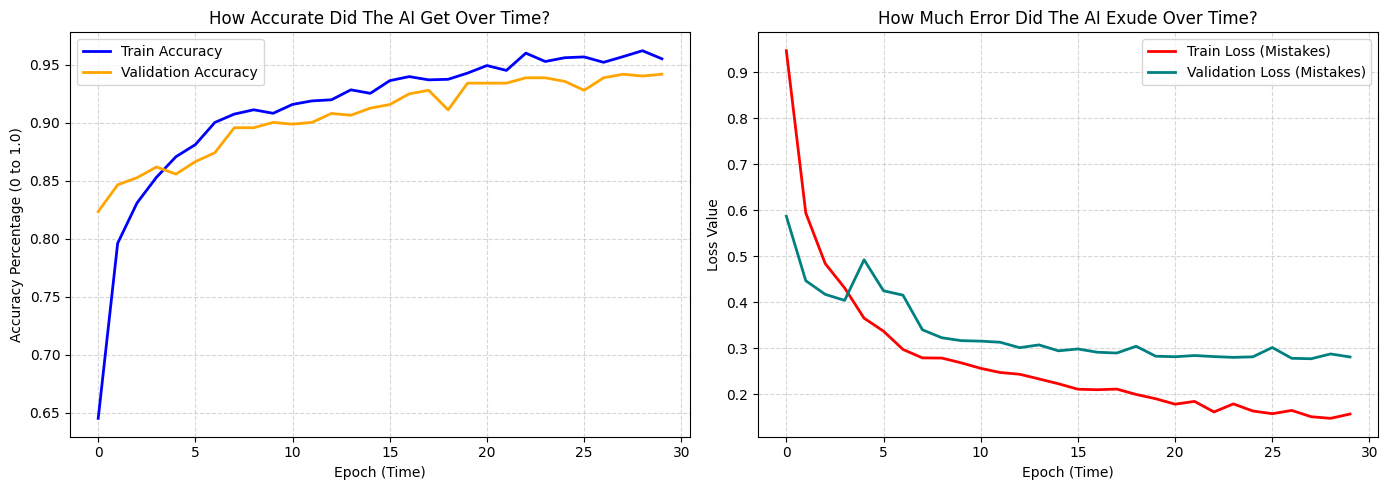

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
Average confidence: 96.94%
----------- PREDICTION TEXT REPORT -----------
                 precision    recall  f1-score   support

   Bengin cases       0.92      0.61      0.73        18
Malignant cases       1.00      0.99      0.99        85
   Normal cases       0.89      0.98      0.93        63

       accuracy                           0.95       166
      macro avg       0.93      0.86      0.89       166
   weighted avg       0.95      0.95      0.94       166



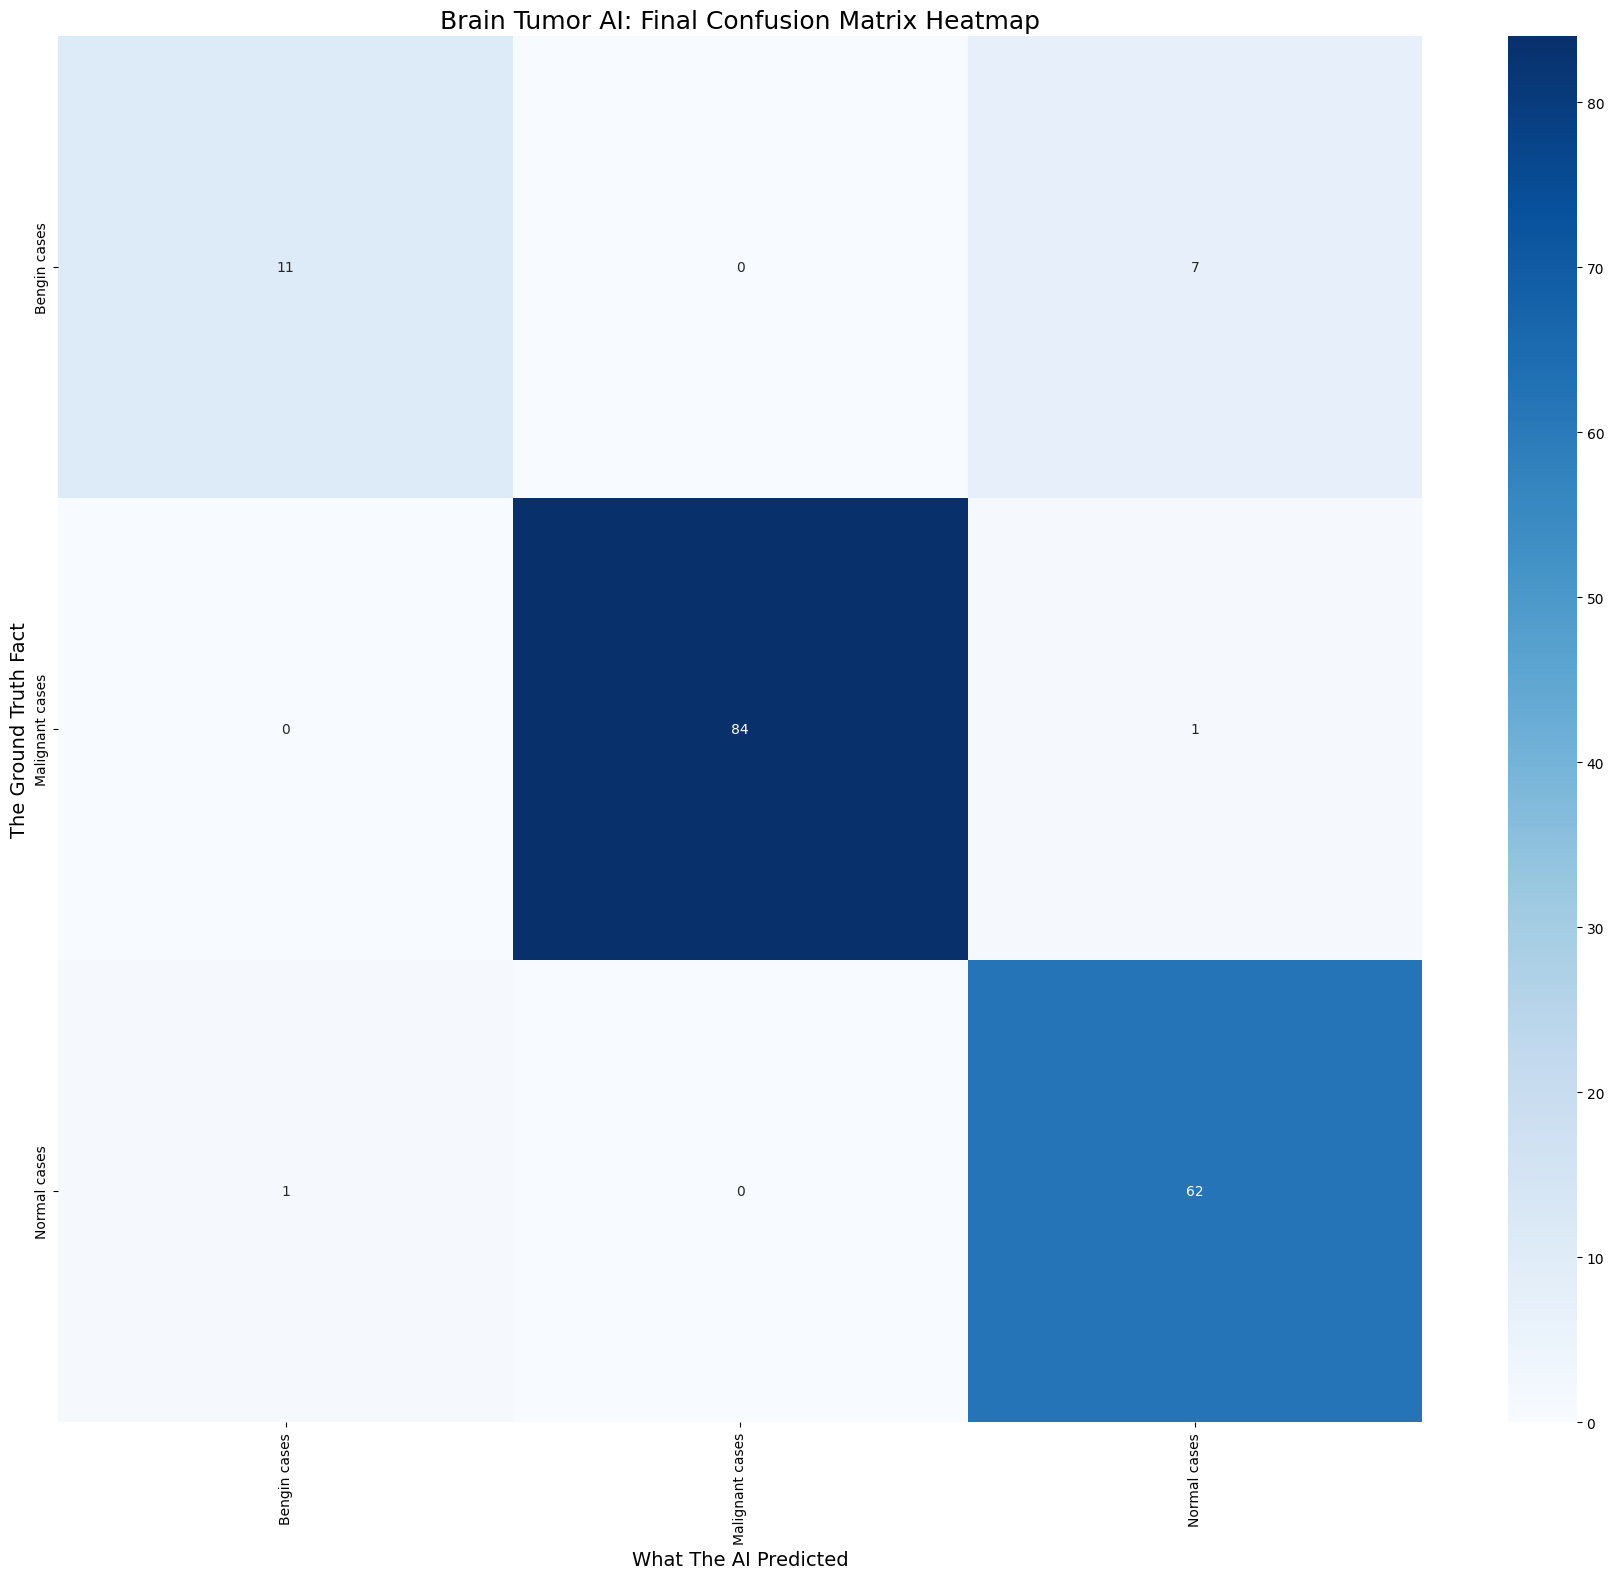

In [28]:
test_generator.reset()

predictions_prob = model.predict(test_generator)

predicted_classes = np.argmax(predictions_prob, axis=1)

true_classes = test_generator.classes

confidence = np.max(predictions_prob, axis=1)
print(f"Average confidence: {confidence.mean():.2%}")

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

In [26]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9065 - loss: 0.3434
🎯 Final Test Accuracy: 94.58%
📉 Final Test Loss/Error: 0.2231


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


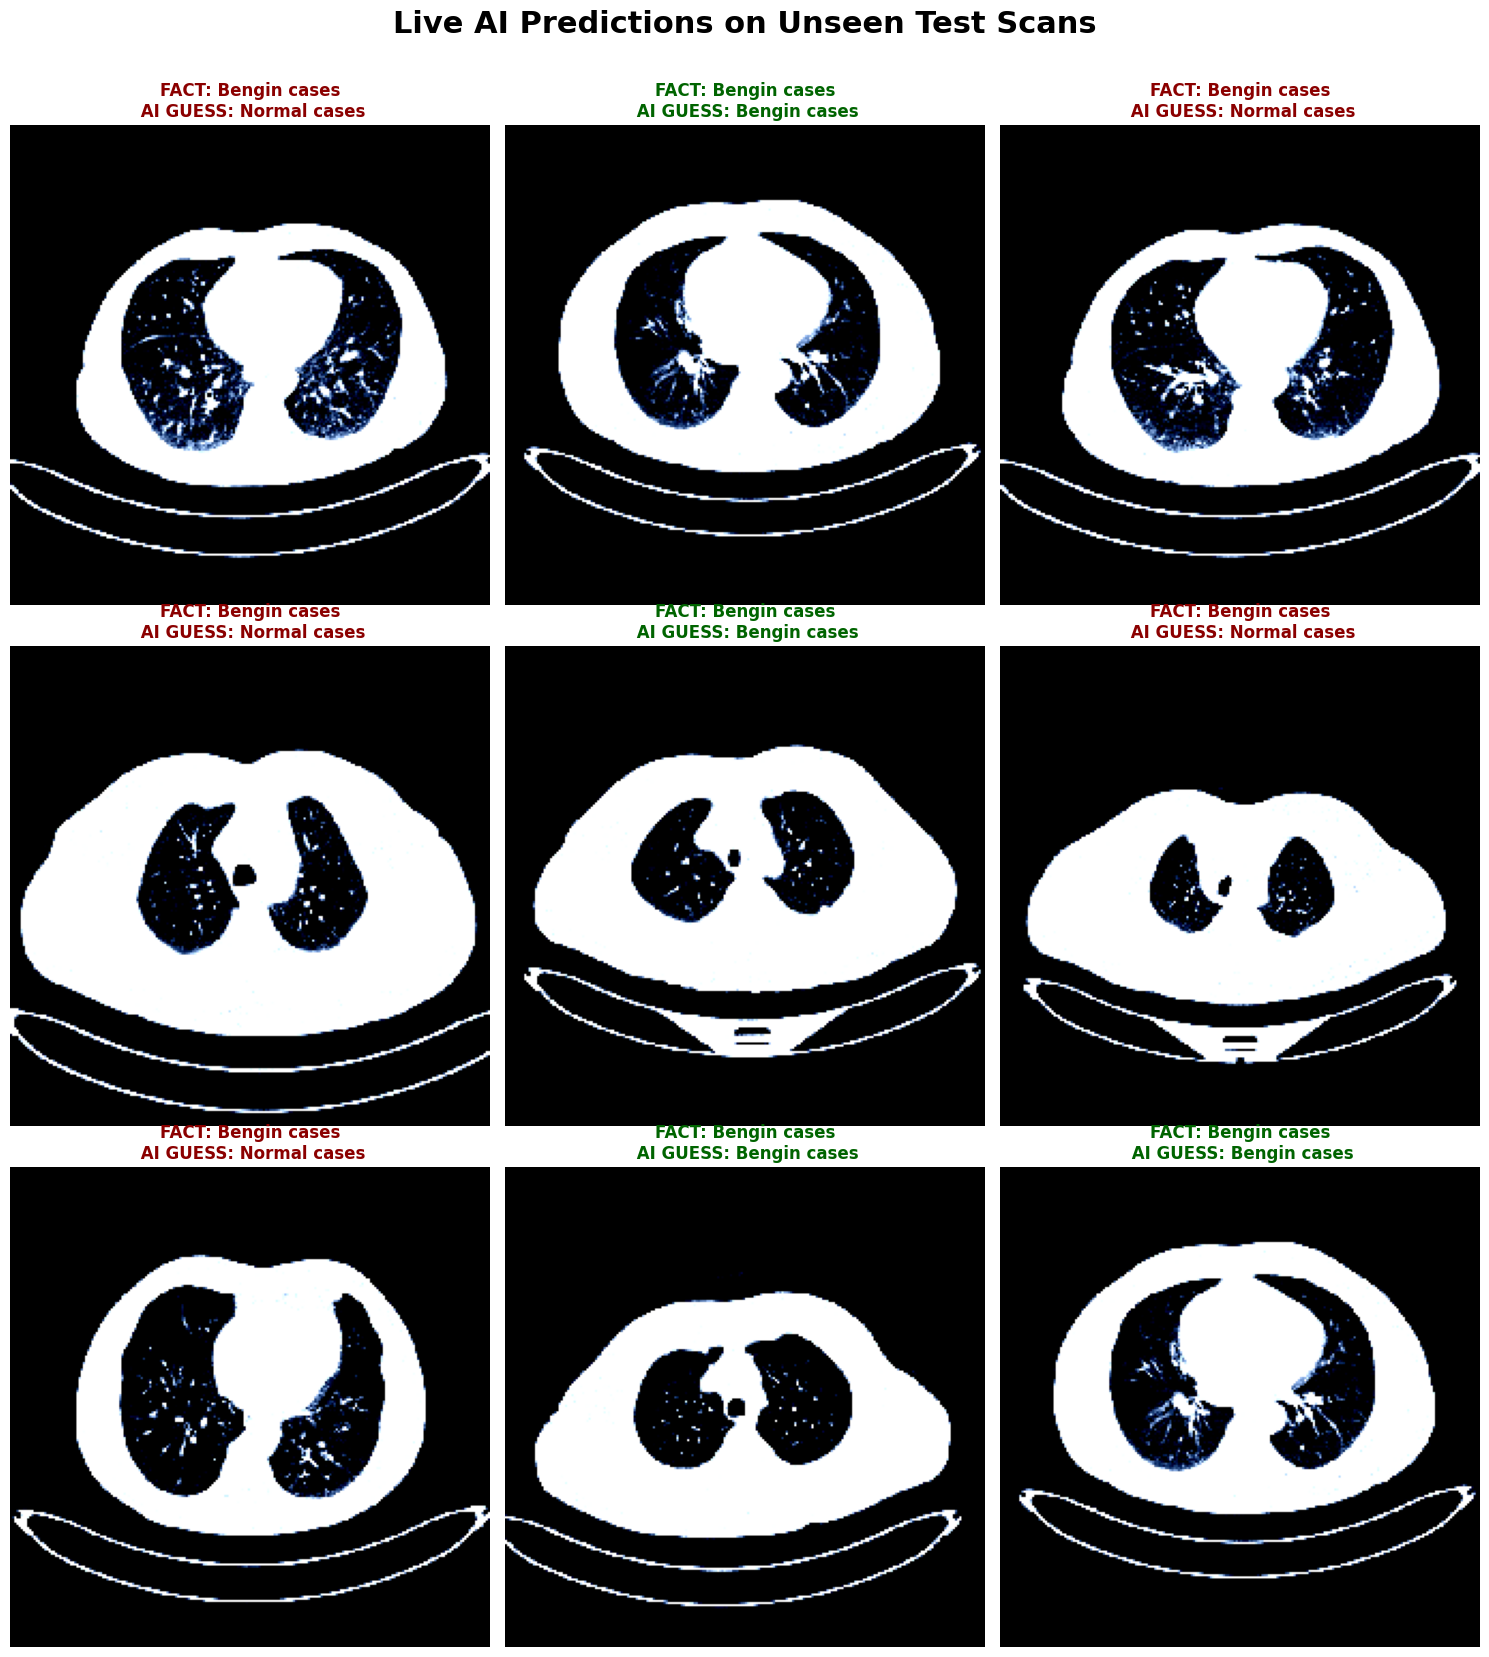

In [27]:
test_generator.reset()
images, onehot_labels = next(test_generator)

preds = model.predict(images)

pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel()

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])

        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"

        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()